<a href="https://colab.research.google.com/github/alcelaser/ML-Project-321991/blob/main/main(with_placeholders)2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Machine Teachers Group Project: PatternMind; Exploring Semantic Structures in Image Collections

## Section 1

Section 1 In section 1 we setup the environment, load the dataset and we start doing some initial data inspection in order to validate the integrity of our dataset.

In [9]:
# Configure environment for GPU detection (must be before TensorFlow import)
import os
os.environ['TF_FORCE_GPU_ALLOW_GROWTH'] = 'true'

# Import core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
from pathlib import Path
import datetime

# Image processing libraries
from PIL import Image

# Sklearn preprocessing
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import precision_recall_fscore_support

# Sklearn model selection
from sklearn.model_selection import train_test_split

# Sklearn metrics
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    silhouette_score
)

# Models for classification/clustering
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Deep Learning for feature extraction
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2

# Clustering Analysis
from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score

# Deep Learning for model building and evaluation
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization, Dropout
from tensorflow.keras.callbacks import EarlyStopping, TensorBoard
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import gc
from tensorflow.keras import models, layers
from tensorflow.keras.initializers import HeNormal
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau


# Configuration
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

# Set random seed for reproducibility
RANDOM_STATE = 67  # we're aware 42 is the industry standard, but we haven't read Hitchhiker's Guide to the Galaxy and 67 is funnier
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

print("Libraries imported successfully!")

# GPU Detection (necessary for CNN training)
print("GPU DETECTION")
print(f"Built with CUDA: {tf.test.is_built_with_cuda()}")
gpus = tf.config.list_physical_devices('GPU')
print(f"GPU Available: {gpus}")

Libraries imported successfully!
GPU DETECTION
Built with CUDA: True
GPU Available: []


### Loading Dataset

**Section 1.2 - Dataset loading** The dataset is organized as a folder-based image collection, where each folder’s name corresponds directly to a category. Each image inside a folder belongs to that same category and is labeled by the name of its parent category.

We load the dataset by first scanning the root directory to retrieve all category folders. Then, for each category, we iterate through its images and store:

* the **path** of each image
* the **label**, which corresponds to the name of the category

Both lists are then combined into a pandas DataFrame, where every image path is paired with its corresponding category. Finally, we display basic dataset statistics, such as the number of images, the number of categories, and the distribution of images across categories.

In [10]:
# === COLAB SETUP: Mount Drive + Unzip dataset + Set path ===

from google.colab import drive
drive.mount('/content/drive')

# Path to your dataset zip on Google Drive
zip_path = '/content/drive/MyDrive/ML-Project /data.zip'

# Unzip into /content/data (local fast storage)
!rm -rf /content/data
!unzip -q "$zip_path" -d /content/data

# Set DATA_DIR for the rest of the notebook
from pathlib import Path
DATA_DIR = Path('/content/data/data')

print("Drive mounted, dataset extracted, DATA_DIR set.")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive mounted, dataset extracted, DATA_DIR set.


In [12]:

# Initialize lists to store image paths and labels
image_paths = []
labels = []

# Scan the data directory for category folders and get all category folders
category_folders = [f for f in DATA_DIR.iterdir() if f.is_dir()]
category_folders = sorted(category_folders)

print(f"Found {len(category_folders)} categories")

# Iterate through each category folder
for category_folder in category_folders:
    category_name = category_folder.name

    # Find all image files in the category folder
    # Support common image formats: jpg, jpeg, png, bmp
    image_files = list(category_folder.glob('*.jpg')) + \
                  list(category_folder.glob('*.jpeg')) + \
                  list(category_folder.glob('*.png')) + \
                  list(category_folder.glob('*.bmp'))

    # Add to our lists
    for img_path in image_files:
        image_paths.append(str(img_path))
        labels.append(category_name)

# Create a DataFrame
df = pd.DataFrame({
    'image_path': image_paths,
    'category': labels
})

# Display basic information
print(f"\nDataset shape: {df.shape}")
print(f"Total number of images: {df.shape[0]:,}")
print(f"Number of categories: {df['category'].nunique()}")


print("\nCategory Distribution:")
category_counts = df['category'].value_counts().sort_index()
print(f"\nImages per category (first 10):")
display(category_counts.head(10))

print(f"\nStatistics:")
print(f"  Mean images per category: {category_counts.mean():.1f}")
print(f"  Median images per category: {category_counts.median():.1f}")
print(f"  Min images per category: {category_counts.min()}")
print(f"  Max images per category: {category_counts.max()}")

print("\n First few rows of the dataset:")
display(df.head(10))

Found 233 categories

Dataset shape: (25557, 2)
Total number of images: 25,557
Number of categories: 233

Category Distribution:

Images per category (first 10):


,count
category,
airplanes,720
ak47,89
american-flag,88
backpack,138
baseball-glove,137
bat,97
bathtub,212
bear,94
billiards,251



Statistics:
  Mean images per category: 109.7
  Median images per category: 92.0
  Min images per category: 72
  Max images per category: 761

 First few rows of the dataset:


,image_path,category
0,/content/data/data/airplanes/airplanes-101_535...,airplanes
1,/content/data/data/airplanes/airplanes-101_440...,airplanes
2,/content/data/data/airplanes/airplanes-101_386...,airplanes
3,/content/data/data/airplanes/airplanes-101_266...,airplanes
4,/content/data/data/airplanes/airplanes-101_261...,airplanes
5,/content/data/data/airplanes/airplanes-101_120...,airplanes
6,/content/data/data/airplanes/airplanes-101_315...,airplanes
7,/content/data/data/airplanes/airplanes-101_111...,airplanes
8,/content/data/data/airplanes/airplanes-101_01.jpg,airplanes
9,/content/data/data/airplanes/airplanes-101_705...,airplanes


### Dataset Overview and Validation

In [ ]:
# Sample a few images to check dimensions and formats
sample_size = min(100, len(df))
sample_indices = np.random.choice(len(df), size=sample_size, replace=False)

widths = []
heights = []
formats = []
corrupted_images = []

for idx in sample_indices:
    img_path = df.iloc[idx]['image_path']
    try:
        img = Image.open(img_path)
        widths.append(img.width)
        heights.append(img.height)
        formats.append(img.format)
        img.close()
    except Exception as e:
        corrupted_images.append(img_path)
        print(f"Warning: Could not read {img_path}: {e}")

if len(corrupted_images) > 0:
    print(f"\nFound {len(corrupted_images)} corrupted images")
else:
    print("\nAll sampled images are valid")

print(f"\nImage Dimensions (from {sample_size} samples):")
print(f"Width  - Min: {min(widths)}px, Max: {max(widths)}px, Mean: {np.mean(widths):.1f}px")
print(f"Height - Min: {min(heights)}px, Max: {max(heights)}px, Mean: {np.mean(heights):.1f}px")
print(f"\nImage Formats: {set(formats)}")

# Analyze category distribution
print("\nCategory Distribution Analysis:")

category_counts = df['category'].value_counts()
print(f"\nTop 10 most common categories:")
display(category_counts.head(10))

print(f"\nTop 10 least common categories:")
display(category_counts.tail(10))

# Check for class imbalance
imbalance_ratio = category_counts.max() / category_counts.min()
print(f"\nClass Imbalance Ratio: {imbalance_ratio:.2f}x")
if imbalance_ratio > 3:
    print("Significant class imbalance")
else:
    print("Relatively balanced")

# Store key information for later use
print("\nDataset Summary:")
print(f"Total Images: {len(df):,}")
print(f"Total Categories: {df['category'].nunique()}")
print(f"Average Images per Category: {len(df) / df['category'].nunique():.1f}")


All sampled images are valid

Image Dimensions (from 100 samples):
Width  - Min: 130px, Max: 1301px, Mean: 397.2px
Height - Min: 131px, Max: 976px, Mean: 342.4px

Image Formats: {'JPEG'}

Category Distribution Analysis:

Top 10 most common categories:


,count
category,
clutter,761
airplanes,720
motorbikes,719
faces-easy,396
t-shirt,330
hammock,257
billiards,251
horse,246
ladder,223



Top 10 least common categories:


,count
category,
starfish,75
floppy-disk,75
skunk,74
kangaroo,74
galaxy,74
golden-gate-bridge,73
harpsichord,73
scorpion,73
sunflower,73



Class Imbalance Ratio: 10.57x
Significant class imbalance

Dataset Summary:
Total Images: 25,557
Total Categories: 233
Average Images per Category: 109.7


### Visualizing Sample Images

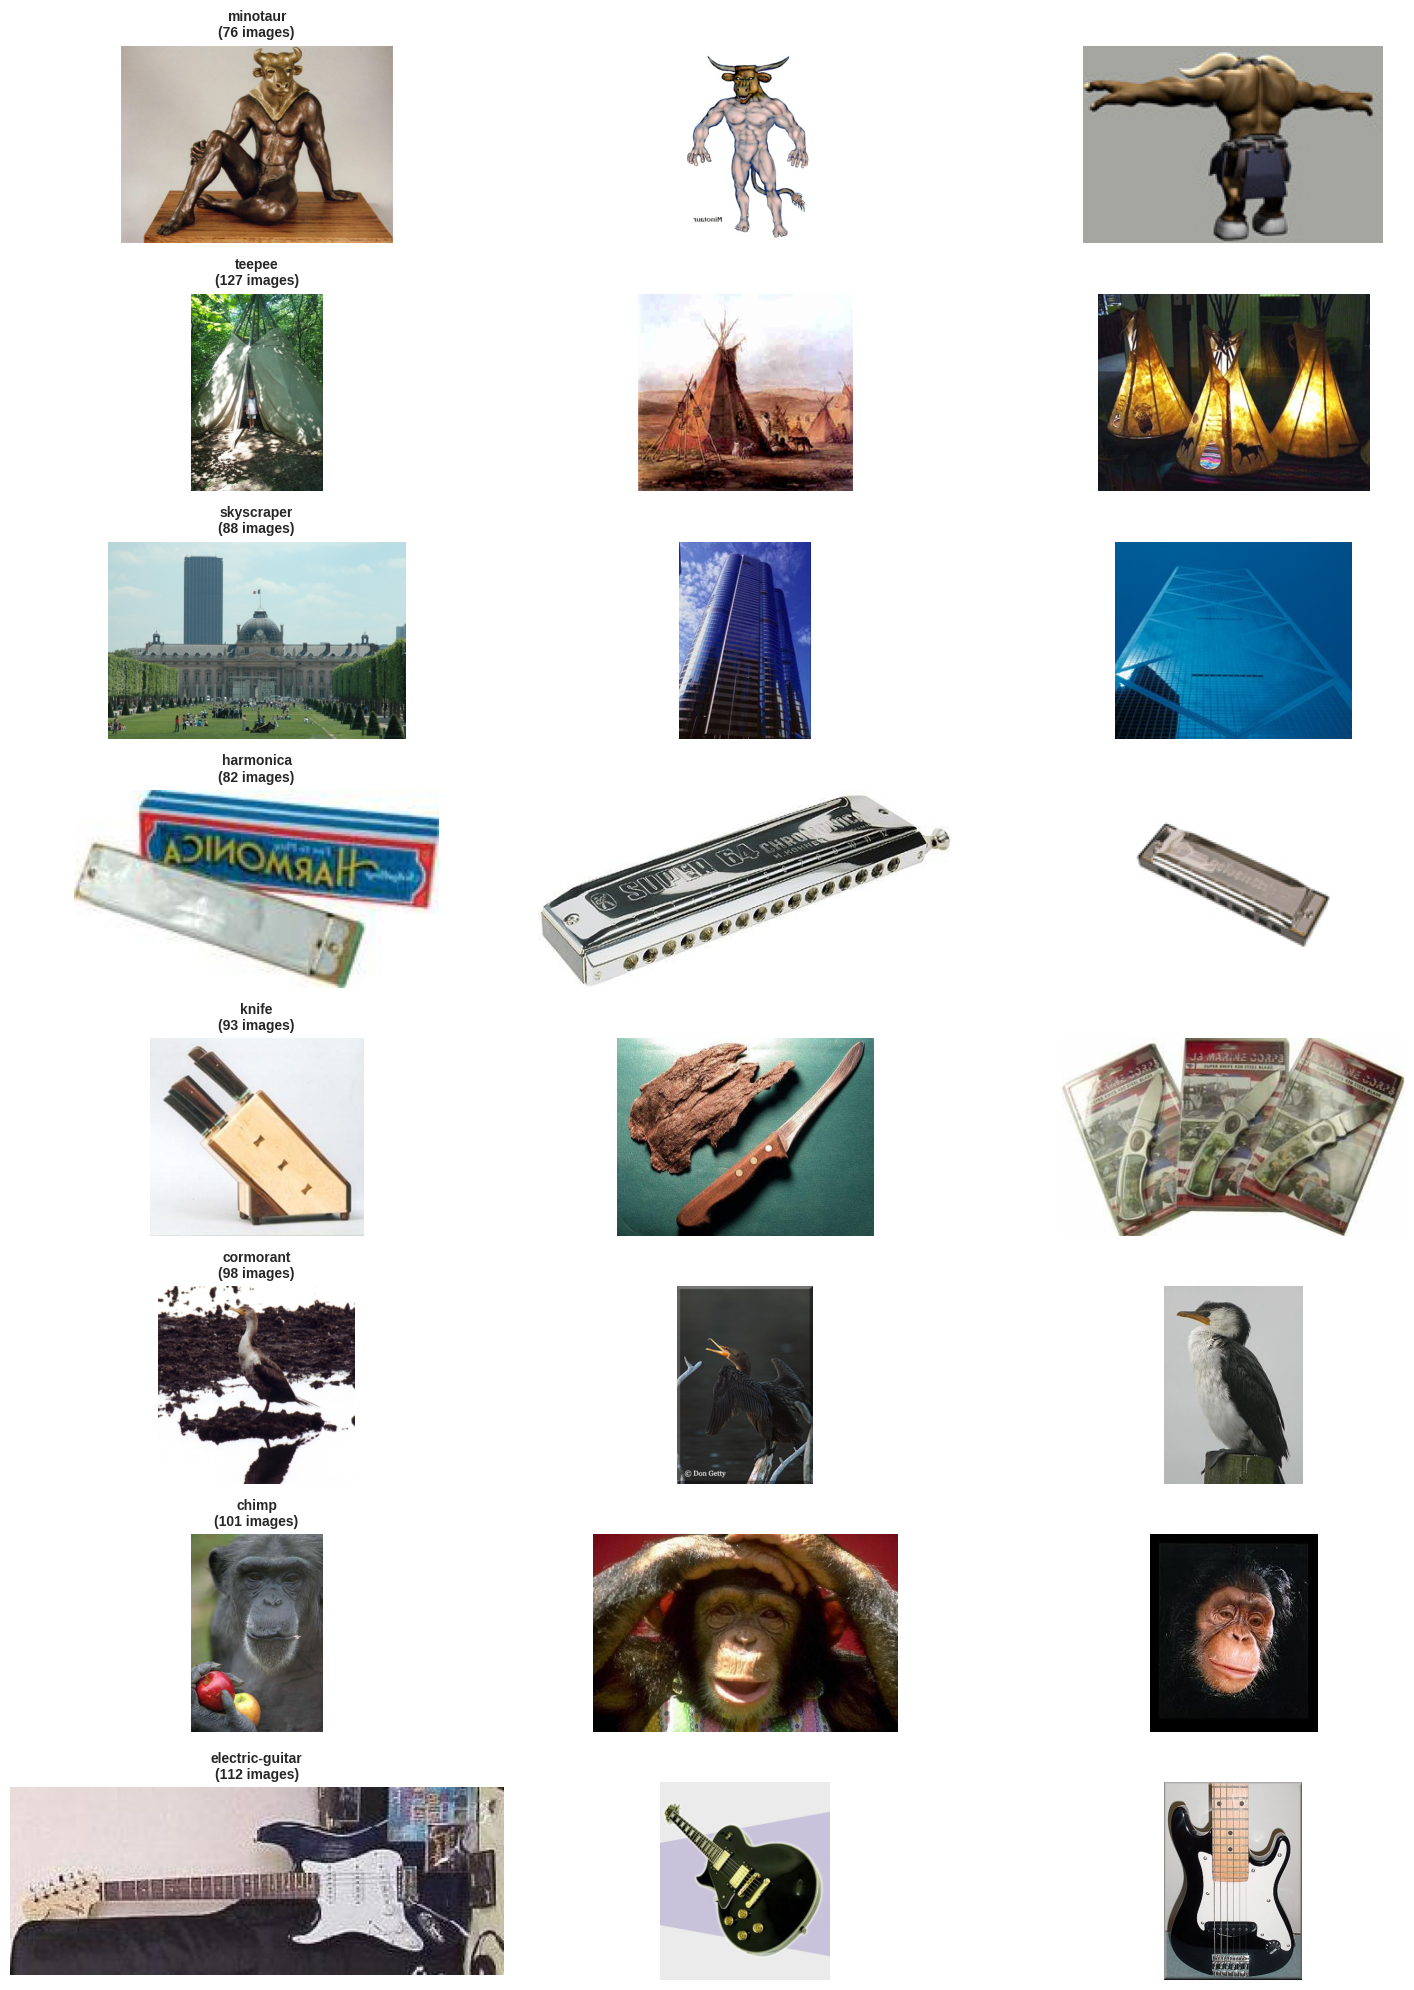


Category Name Analysis:
Shortest category name: 'cd' (2 chars)
Longest category name: 'self-propelled-lawn-mower' (25 chars)

All categories (233 total):
['airplanes', 'ak47', 'american-flag', 'backpack', 'baseball-glove', 'bat', 'bathtub', 'bear', 'billiards', 'binoculars', 'birdbath', 'blimp', 'bonsai', 'boom-box', 'bowling-ball', 'bowling-pin', 'boxing-glove', 'brain', 'breadmaker', 'buddha', 'bulldozer', 'butterfly', 'cactus', 'cake', 'calculator', 'camel', 'cannon', 'car-side', 'car-tire', 'cartman', 'cd', 'centipede', 'cereal-box', 'chandelier', 'chess-board', 'chimp', 'chopsticks', 'clutter', 'cockroach', 'coffee-mug', 'coffin', 'coin', 'comet', 'computer-keyboard', 'computer-mouse', 'conch', 'cormorant', 'covered-wagon', 'cowboy-hat', 'desk-globe', 'diamond-ring', 'dice', 'dog', 'dolphin-101', 'doorknob', 'drinking-straw', 'duck', 'eiffel-tower', 'electric-guitar', 'elephant', 'elk', 'ewer', 'eyeglasses', 'faces-easy', 'fern', 'fighter-jet', 'fire-extinguisher', 'fire-hydrant'

In [ ]:
# Visualize sample images from different categories
n_categories_to_show = 8
n_images_per_category = 3

# Select random categories
random_categories = np.random.choice(df['category'].unique(),
                                     size=min(n_categories_to_show, df['category'].nunique()),
                                     replace=False)

# Create figure
fig, axes = plt.subplots(n_categories_to_show, n_images_per_category,
                         figsize=(15, 2.5*n_categories_to_show))

if n_categories_to_show == 1:
    axes = axes.reshape(1, -1)

for i, category in enumerate(random_categories):
    # Get images from this category
    category_df = df[df['category'] == category]

    # Sample random images
    sampled_images = category_df.sample(n=min(n_images_per_category, len(category_df)))

    for j, (idx, row) in enumerate(sampled_images.iterrows()):
        img_path = row['image_path']

        try:
            img = Image.open(img_path)

            # Display image
            if n_categories_to_show > 1:
                ax = axes[i, j]
            else:
                ax = axes[j]

            ax.imshow(img)
            ax.axis('off')

            if j == 0:  # Add category label to first image in row
                ax.set_title(f"{category}\n({len(category_df)} images)",
                           fontsize=10, fontweight='bold')

            img.close()

        except Exception as e:
            print(f"Error loading {img_path}: {e}")

plt.tight_layout()

# Create the 'images' directory if it doesn't exist
import os
os.makedirs('images', exist_ok=True)

plt.savefig('images/sample_images_grid.png', dpi=150, bbox_inches='tight')
plt.show()

# Additional: Show category name statistics
print("\nCategory Name Analysis:")
print(f"Shortest category name: '{min(df['category'].unique(), key=len)}' ({len(min(df['category'].unique(), key=len))} chars)")
print(f"Longest category name: '{max(df['category'].unique(), key=len)}' ({len(max(df['category'].unique(), key=len))} chars)")
print(f"\nAll categories ({len(df['category'].unique())} total):")
print(sorted(df['category'].unique()))

## Section 2: EDA and Feature Engineering

###Category Distribution Visualization

In [ ]:
top_n = 20
top_counts = category_counts.head(top_n)

y_labels = top_counts.index[::-1]
x_values = top_counts.values[::-1]

fig = go.Figure()

fig.add_trace(
    go.Bar(
        x=x_values,
        y=y_labels,
        orientation='h'
    )
)

fig.update_layout(
    title=f"Top {top_n} categories by image count",
    xaxis_title="Number of images",
    yaxis_title="Category",
    height=600
)

fig.show()

In [ ]:
bottom_n = 20

bottom_counts = category_counts.tail(bottom_n)

y_labels = bottom_counts.index[::-1]
x_values = bottom_counts.values[::-1]

fig_bottom = go.Figure()

fig_bottom.add_trace(
    go.Bar(
        x=x_values,
        y=y_labels,
        orientation='h'
    )
)

fig_bottom.update_layout(
    title=f"Bottom {bottom_n} categories by image count",
    xaxis_title="Number of images",
    yaxis_title="Category",
    height=600
)

fig_bottom.show()

In [ ]:
# Distribution values
values = category_counts.values

mean_val = np.mean(values)
median_val = np.median(values)

fig_hist = go.Figure()

# Histogram
fig_hist.add_trace(
    go.Histogram(
        x=values,
        nbinsx=30,
        name="Distribution"
    )
)

# Mean line
fig_hist.add_trace(
    go.Scatter(
        x=[mean_val, mean_val],
        y=[0, max(np.histogram(values, bins=30)[0])],
        mode="lines",
        line=dict(color="red", width=2, dash="dash"),
        name=f"Mean ({mean_val:.1f})"
    )
)

# Median line
fig_hist.add_trace(
    go.Scatter(
        x=[median_val, median_val],
        y=[0, max(np.histogram(values, bins=30)[0])],
        mode="lines",
        line=dict(color="blue", width=2, dash="dot"),
        name=f"Median ({median_val:.1f})"
    )
)

fig_hist.update_layout(
    title="Distribution of images per category (with mean & median)",
    xaxis_title="Images per category",
    yaxis_title="Number of categories",
    legend=dict(
        x=0.7, y=0.95,
        bgcolor="rgba(255,255,255,0.5)"
    )
)

fig_hist.show()


In [ ]:
fig_box = go.Figure()

fig_box.add_trace(
    go.Box(
        y=values,
        boxpoints='all',
        jitter=0,
        pointpos=0,
        marker=dict(color='black', size=4),
        line=dict(color='red'),
        fillcolor='rgba(255, 200, 200, 0.3)'
    )
)

fig_box.update_layout(
    title="Box Plot of Category Sizes",
    yaxis_title="Number of images",
    height=500
)

fig_box.show()


In [ ]:
mean_val = np.mean(values)
median_val = np.median(values)
std_val = np.std(values)
min_val = np.min(values)
max_val = np.max(values)
q1 = np.quantile(values, 0.25)
q3 = np.quantile(values, 0.75)

most_common_cat = category_counts.index[0]
most_common_val = category_counts.values[0]

least_common_cat = category_counts.index[-1]
least_common_val = category_counts.values[-1]

imbalance_ratio = max_val / min_val

fig_stats = go.Figure(
    data=[
        go.Table(
            header=dict(
                values=["<b>CATEGORY DISTRIBUTION STATISTICS</b>"],
                fill_color='lightgray',
                align='left',
                font=dict(size=14)
            ),
            cells=dict(
                values=[[
                    f"Total Categories: {len(category_counts)}",
                    f"Total Images: {category_counts.sum():,}",
                    "",
                    "Images per Category:",
                    f"• Mean: {mean_val:.2f}",
                    f"• Median: {median_val:.2f}",
                    f"• Std Dev: {std_val:.2f}",
                    f"• Min: {min_val}",
                    f"• Max: {max_val}",
                    f"• Q1: {q1:.2f}",
                    f"• Q3: {q3:.2f}",
                    "",
                    f"Class Imbalance Ratio: {imbalance_ratio:.2f}x",
                    "",
                    f"Most Common: {most_common_cat} ({most_common_val} images)",
                    f"Least Common: {least_common_cat} ({least_common_val} images)"
                ]],
                align='left',
                font=dict(size=12),
                height=28,
                fill_color='rgb(245, 240, 220)'  # beige come nel main
            )
        )
    ]
)

fig_stats.update_layout(height=700)
fig_stats.show()


###Feature Extraction Using Pre-Trained Model

In [14]:
# Feature Extraction using MobileNetV2
# Load pre-trained MobileNetV2 model without top classification layer, this is pur feature extractor
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,  # Remove classification head
    weights='imagenet',
    pooling='avg'  # Global average pooling to get fixed-size feature vector
)

print(f"Feature vector dimension: {base_model.output_shape[1]}")

# Function to preprocess and extract features from an image
def extract_features(img_path, target_size=(224, 224)):
    """Extract features from a single image using MobileNetV2"""
    try:
        # Load and preprocess image
        img = tf.keras.preprocessing.image.load_img(img_path, target_size=target_size)
        img_array = tf.keras.preprocessing.image.img_to_array(img)
        img_array = np.expand_dims(img_array, axis=0)
        img_array = tf.keras.applications.mobilenet_v2.preprocess_input(img_array)

        # Extract features
        features = base_model.predict(img_array, verbose=0)
        return features.flatten()
    except Exception as e:
        print(f"Error processing {img_path}: {e}")
        return None

# Extract features for all images (with progress tracking)
features_list = []
valid_indices = []
failed_images = []

# Process images in batches for efficiency
batch_size = 32
n_batches = int(np.ceil(len(df) / batch_size))

for batch_idx in range(n_batches):
    start_idx = batch_idx * batch_size
    end_idx = min((batch_idx + 1) * batch_size, len(df))

    batch_images = []
    batch_indices = []

    # Load batch of images
    for idx in range(start_idx, end_idx):
        img_path = df.iloc[idx]['image_path']
        try:
            img = tf.keras.preprocessing.image.load_img(img_path, target_size=(224, 224))
            img_array = tf.keras.preprocessing.image.img_to_array(img)
            batch_images.append(img_array)
            batch_indices.append(idx)
        except Exception as e:
            failed_images.append(img_path)
            continue

    if len(batch_images) > 0:
        # Preprocess batch
        batch_images = np.array(batch_images)
        batch_images = tf.keras.applications.mobilenet_v2.preprocess_input(batch_images)

        # Extract features for batch
        batch_features = base_model.predict(batch_images, verbose=0)

        # Store features and indices
        for i, features in enumerate(batch_features):
            features_list.append(features)
            valid_indices.append(batch_indices[i])

    # Progress update
    if (batch_idx + 1) % 10 == 0 or (batch_idx + 1) == n_batches:
        progress = ((batch_idx + 1) / n_batches) * 100
        print(f"Progress: {progress:.1f}% ({batch_idx + 1}/{n_batches} batches) - "
              f"{len(features_list)} images processed")

# Convert to numpy array
features_array = np.array(features_list)

# Create cleaned dataframe with only successfully processed images
df_features = df.iloc[valid_indices].copy().reset_index(drop=True)

print(f"Successfully extracted features from: {len(features_list):,} images")
print(f"Failed to process: {len(failed_images)} images")
print(f"Feature matrix shape: {features_array.shape}")
print(f"{features_array.shape[0]:,} samples")
print(f"{features_array.shape[1]} features per image")
print(f"\nMemory usage: {features_array.nbytes / (1024**2):.2f} MB") # For memory usage which was limited under wsl

Feature vector dimension: 1280
Progress: 1.3% (10/799 batches) - 320 images processed
Progress: 2.5% (20/799 batches) - 640 images processed
Progress: 3.8% (30/799 batches) - 960 images processed
Progress: 5.0% (40/799 batches) - 1280 images processed
Progress: 6.3% (50/799 batches) - 1600 images processed
Progress: 7.5% (60/799 batches) - 1920 images processed
Progress: 8.8% (70/799 batches) - 2240 images processed
Progress: 10.0% (80/799 batches) - 2560 images processed
Progress: 11.3% (90/799 batches) - 2880 images processed
Progress: 12.5% (100/799 batches) - 3200 images processed
Progress: 13.8% (110/799 batches) - 3520 images processed
Progress: 15.0% (120/799 batches) - 3840 images processed
Progress: 16.3% (130/799 batches) - 4160 images processed
Progress: 17.5% (140/799 batches) - 4480 images processed
Progress: 18.8% (150/799 batches) - 4800 images processed
Progress: 20.0% (160/799 batches) - 5120 images processed
Progress: 21.3% (170/799 batches) - 5440 images processed
Pr

### Feature Distribution Analysis

In [ ]:
# Analyze feature distributions
print("Feature Distribution Analysis")

# Basic statistics
feature_means = features_array.mean(axis=0)
feature_stds = features_array.std(axis=0)
feature_mins = features_array.min(axis=0)
feature_maxs = features_array.max(axis=0)

print(f"\nFeature Statistics:")
print(f"  Mean of means: {feature_means.mean():.4f}")
print(f"  Mean of stds:  {feature_stds.mean():.4f}")
print(f"  Global min:    {feature_mins.min():.4f}")
print(f"  Global max:    {feature_maxs.max():.4f}")

# Create comprehensive visualizations

# 1. Distribution of feature means
fig_means = go.Figure()
fig_means.add_trace(
    go.Histogram(
        x=feature_means,
        nbinsx=50
    )
)

fig_means.update_layout(
    title="Distribution of feature means across features",
    xaxis_title="Mean activation value",
    yaxis_title="Number of features"
)

fig_means.show()

# 2. Distribution of feature standard deviations
fig_stds = go.Figure()
fig_stds.add_trace(
    go.Histogram(
        x=feature_stds,
        nbinsx=50
    )
)

fig_stds.update_layout(
    title="Distribution of feature standard deviations",
    xaxis_title="Standard deviation of feature activation",
    yaxis_title="Number of features"
)

fig_stds.show()

# 3. Distribution of feature ranges
feature_ranges = feature_maxs - feature_mins

fig_ranges = go.Figure()
fig_ranges.add_trace(
    go.Histogram(
        x=feature_ranges,
        nbinsx=50
    )
)

fig_ranges.update_layout(
    title="Distribution of feature ranges (max - min)",
    xaxis_title="Range of activation",
    yaxis_title="Number of features"
)

fig_ranges.show()

# 4. Sample feature values across images (first 100 features)
n_features_sample = 100
n_images_sample = min(200, features_array.shape[0])

sample_matrix = features_array[:n_images_sample, :n_features_sample]

fig_sample_feat = go.Figure(
    data=go.Heatmap(
        z=sample_matrix,
        colorbar=dict(title="Activation")
    )
)

fig_sample_feat.update_layout(
    title=f"Activations of first {n_features_sample} features across {n_images_sample} images",
    xaxis_title="Feature index",
    yaxis_title="Image index"
)

fig_sample_feat.show()

# 5. Feature correlation sample (random subset to avoid memory issues)
subset_size = 50
np.random.seed(RANDOM_STATE)
subset_indices = np.random.choice(features_array.shape[1],
                                  size=subset_size,
                                  replace=False)

subset_features = features_array[:, subset_indices]

corr_matrix = np.corrcoef(subset_features.T)

fig_corr = go.Figure(
    data=go.Heatmap(
        z=corr_matrix,
        colorbar=dict(title="Correlation")
    )
)

fig_corr.update_layout(
    title=f"Correlation matrix of {subset_size} random features",
    xaxis_title="Feature index",
    yaxis_title="Feature index"
)

fig_corr.show()

# 6. Distribution of a few sample features
sample_feat_indices = subset_indices[:4]

fig_sample_distr = go.Figure()

for idx in sample_feat_indices:
    fig_sample_distr.add_trace(
        go.Histogram(
            x=features_array[:, idx],
            opacity=0.5,
            name=f"Feature {idx}"
        )
    )

fig_sample_distr.update_layout(
    title="Activation distribution of sample features",
    xaxis_title="Activation value",
    yaxis_title="Number of images",
    barmode='overlay'
)

fig_sample_distr.show()


# Check for zero-variance features
zero_var_features = np.where(feature_stds < 1e-10)[0]
print(f"\nZero-variance features: {len(zero_var_features)}")
if len(zero_var_features) > 0:
    print(f"  These features have no variation and could be removed")

# Check sparsity
sparsity = (features_array == 0).sum() / features_array.size * 100
print(f"\nFeature sparsity: {sparsity:.2f}% (percentage of zero values)")

Feature Distribution Analysis

Feature Statistics:
  Mean of means: 0.3831
  Mean of stds:  0.5713
  Global min:    0.0000
  Global max:    6.0000



Zero-variance features: 0

Feature sparsity: 28.37% (percentage of zero values)


per claudio per la comprensione dei grafici per il markdown:
* primo grafico: mostra la media di attivazione di ogni feature, la maggior parte sta tra 0.3 e 0.45 quindi sono attive, alcune sono vicine a zero ma non vuol dire che non si attivino, è solo che sono molto selettive
* secondo grafico: infatti come vediamo nel secondo grafico la std sta più o meno tra 0.4 e 0.65, quindi le attivazioni cambiano da immagine a immagine, una sola feature ha std vicina allo zero
* terzo grafico: dal terzo grafico si vede che quasi tutte le feature hanno un range di attivazione alto e che quindi non sono piatte, cambiano molto da immagine ad immagine e sono informative. range piccoli indicano feature spente ma qui non c'è ne sono
* quarto grafico: questo serve per vedere quali feature si attivano su quali immagini, ogni riga è un immagine ogni colonna è una feature, se una colonna è tutta viola la feature non si attiva mai, se è tutta gialla si attiva sempre.
Nel grafico ci sono colonne più attive e altre meno attive ma non ci sono colonne tutte accese o tutte spente, quindi vuol dire in media le feature sia attivano solo su immagini specifiche e questo indica che il layer sta lavorando bene
* quinto grafico: questa è una matrice di correlazione per ogni coppia di feature misura se e quanto si comportano similmente, viola indipendenti, giallo uguali, viola molto scuro opposte. la matrice è quasi tutta viola tranne la diagonale, vuol dire che le feature non sono correlate, che non ci sono feature inutili o che si copiano, è un segnale positivo e indica un layer ricco. (la diagonale è gialla perche è dove le feature si confrontano con loro stesse)
* sesto grafico: rappresenta 4 curve di attivazione, di 4 feature diverse, tutte e 4 sono molto alte vicino allo 0 e poi vanno ad appiattirsi tra 4 e 5, questo vuol dire che sono quasi sempre spente ma poi si attivano molto forte solo quando trovano un determinato pattern

### Dimension Reduction and Visualisation of High-dimensional features

In [ ]:
# For visualization, we'll use a subset
max_samples_for_viz = 5000
if len(features_array) > max_samples_for_viz:
    print(f"\nDataset has {len(features_array)} samples - using stratified sample of {max_samples_for_viz} for visualization")
    # Stratified sampling to maintain category proportions
    from sklearn.model_selection import train_test_split
    _, X_viz, _, y_viz = train_test_split(
        features_array,
        df_features['category'],
        train_size=(len(features_array) - max_samples_for_viz),
        stratify=df_features['category'],
        random_state=RANDOM_STATE
    )
else:
    X_viz = features_array
    y_viz = df_features['category']

print(f"Visualization sample size: {len(X_viz)} images")

# 1. PCA - Principal Component Analysis
print("\n1. Applying PCA...")
pca_2d = PCA(n_components=2, random_state=RANDOM_STATE)
pca_3d = PCA(n_components=3, random_state=RANDOM_STATE)

X_pca_2d = pca_2d.fit_transform(X_viz)
X_pca_3d = pca_3d.fit_transform(X_viz)

print(f"PCA 2D: Explained variance: {pca_2d.explained_variance_ratio_.sum()*100:.2f}%")
print(f"PCA 3D: Explained variance: {pca_3d.explained_variance_ratio_.sum()*100:.2f}%")

# 2. t-SNE - T-distributed Stochastic Neighbor Embedding
print("\n2. Applying t-SNE (this may take a few minutes)...")

# Use PCA preprocessing for t-SNE (recommended practice)
pca_50 = PCA(n_components=50, random_state=RANDOM_STATE)
X_pca_50 = pca_50.fit_transform(X_viz)

tsne_2d = TSNE(n_components=2, random_state=RANDOM_STATE, perplexity=30, max_iter=1000)
X_tsne_2d = tsne_2d.fit_transform(X_pca_50)


# Create visualizations

# Limit categories for color clarity (show top 20 by frequency)
category_counts = pd.Series(y_viz).value_counts()
top_categories = category_counts.head(20).index.tolist()
color_map = {cat: i for i, cat in enumerate(top_categories)}

# Assign colors: top categories get distinct colors, others are gray
colors_pca = [color_map.get(cat, -1) for cat in y_viz]
colors_tsne = colors_pca.copy()

# Create DataFrame for plotting
viz_df = pd.DataFrame({
    'PCA1': X_pca_2d[:, 0],
    'PCA2': X_pca_2d[:, 1],
    'PCA3': X_pca_3d[:, 2],
    'tSNE1': X_tsne_2d[:, 0],
    'tSNE2': X_tsne_2d[:, 1],
    'category': y_viz.values if hasattr(y_viz, 'values') else y_viz,
    'is_top20': [cat in top_categories for cat in y_viz]
})

# 1. PCA 2D Scatter Plot
fig_pca2d = go.Figure()

# Plot non-top categories in gray first (background)
df_other = viz_df[~viz_df['is_top20']]
fig_pca2d.add_trace(go.Scatter(
    x=df_other['PCA1'], y=df_other['PCA2'],
    mode='markers',
    marker=dict(size=4, color='lightgray', opacity=0.3),
    name='Other categories',
    hoverinfo='skip'
))

# Plot top 20 categories with distinct colors
for cat in top_categories:
    df_cat = viz_df[viz_df['category'] == cat]
    fig_pca2d.add_trace(go.Scatter(
        x=df_cat['PCA1'], y=df_cat['PCA2'],
        mode='markers',
        marker=dict(size=6, opacity=0.7),
        name=cat[:20],  # Truncate long names
        hovertemplate=f'<b>{cat}</b><br>PC1: %{{x:.2f}}<br>PC2: %{{y:.2f}}<extra></extra>'
    ))

fig_pca2d.update_layout(
    title=f'PCA 2D Projection ({pca_2d.explained_variance_ratio_.sum()*100:.1f}% variance explained)',
    xaxis_title=f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)',
    yaxis_title=f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)',
    height=600,
    legend=dict(font=dict(size=9), itemsizing='constant')
)
fig_pca2d.show()

# 2. t-SNE 2D Scatter Plot
fig_tsne = go.Figure()

# Plot non-top categories in gray first
fig_tsne.add_trace(go.Scatter(
    x=df_other['tSNE1'], y=df_other['tSNE2'],
    mode='markers',
    marker=dict(size=4, color='lightgray', opacity=0.3),
    name='Other categories',
    hoverinfo='skip'
))

# Plot top 20 categories
for cat in top_categories:
    df_cat = viz_df[viz_df['category'] == cat]
    fig_tsne.add_trace(go.Scatter(
        x=df_cat['tSNE1'], y=df_cat['tSNE2'],
        mode='markers',
        marker=dict(size=6, opacity=0.7),
        name=cat[:20],
        hovertemplate=f'<b>{cat}</b><br>tSNE1: %{{x:.2f}}<br>tSNE2: %{{y:.2f}}<extra></extra>'
    ))

fig_tsne.update_layout(
    title='t-SNE 2D Projection (Local Structure Preserved)',
    xaxis_title='t-SNE Dimension 1',
    yaxis_title='t-SNE Dimension 2',
    height=600,
    legend=dict(font=dict(size=9), itemsizing='constant')
)
fig_tsne.show()

# 3. PCA 3D Interactive Plot
fig_pca3d = go.Figure()

for cat in top_categories[:10]:  # Limit to 10 for 3D clarity
    df_cat = viz_df[viz_df['category'] == cat]
    fig_pca3d.add_trace(go.Scatter3d(
        x=df_cat['PCA1'], y=df_cat['PCA2'], z=df_cat['PCA3'],
        mode='markers',
        marker=dict(size=4, opacity=0.7),
        name=cat[:20],
        hovertemplate=f'<b>{cat}</b><extra></extra>'
    ))

fig_pca3d.update_layout(
    title='PCA 3D Projection (Top 10 Categories)',
    scene=dict(
        xaxis_title=f'PC1 ({pca_3d.explained_variance_ratio_[0]*100:.1f}%)',
        yaxis_title=f'PC2 ({pca_3d.explained_variance_ratio_[1]*100:.1f}%)',
        zaxis_title=f'PC3 ({pca_3d.explained_variance_ratio_[2]*100:.1f}%)'
    ),
    height=600
)
fig_pca3d.show()

# 4. Explained Variance Plot
pca_full = PCA(n_components=50, random_state=RANDOM_STATE)
pca_full.fit(X_viz)
cumulative_var = np.cumsum(pca_full.explained_variance_ratio_) * 100

fig_var = go.Figure()
fig_var.add_trace(go.Bar(
    x=list(range(1, 51)),
    y=pca_full.explained_variance_ratio_ * 100,
    name='Individual',
    marker_color='#2E86DE'
))
fig_var.add_trace(go.Scatter(
    x=list(range(1, 51)),
    y=cumulative_var,
    mode='lines+markers',
    name='Cumulative',
    line=dict(color='#EE5A6F', width=2)
))

# Add threshold line at 90%
fig_var.add_hline(y=90, line_dash="dash", line_color="green",
                  annotation_text="90% threshold")

n_components_90 = np.argmax(cumulative_var >= 90) + 1
fig_var.update_layout(
    title=f'PCA Explained Variance (90% at {n_components_90} components)',
    xaxis_title='Principal Component',
    yaxis_title='Explained Variance (%)',
    height=450,
    legend=dict(yanchor="top", y=0.99, xanchor="right", x=0.99)
)
fig_var.show()


print(f"PCA Analysis:")
print(f"First 2 components capture: {pca_2d.explained_variance_ratio_.sum()*100:.2f}% of variance")
print(f"First 3 components capture: {pca_3d.explained_variance_ratio_.sum()*100:.2f}% of variance")


Dataset has 25557 samples - using stratified sample of 5000 for visualization
Visualization sample size: 5000 images

1. Applying PCA...
PCA 2D: Explained variance: 5.15%
PCA 3D: Explained variance: 6.80%

2. Applying t-SNE (this may take a few minutes)...


PCA Analysis:
First 2 components capture: 5.15% of variance
First 3 components capture: 6.80% of variance


What we will use t-sne and PCA for + description of output for pca and its implications for cluster analysis

## Section 3 Data Preprocessing

### Feature Scaling and Label Encoding

In [15]:
# Encode labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(df_features['category'])

print(f"\nLabel Encoding:")
print(f"  Number of classes: {len(label_encoder.classes_)}")
print(f"  Classes: {label_encoder.classes_[:10]}..." if len(label_encoder.classes_) > 10 else f"  Classes: {label_encoder.classes_}")

# Define NB_CATEGORIES here, so it's available for subsequent models
NB_CATEGORIES = len(label_encoder.classes_)

# Feature scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features_array)

print(f"\nFeature Scaling:")
print(f"  Original features - Mean: {features_array.mean():.4f}, Std: {features_array.std():.4f}")
print(f"  Scaled features   - Mean: {X_scaled.mean():.4f}, Std: {X_scaled.std():.4f}")


Label Encoding:
  Number of classes: 233
  Classes: ['airplanes' 'ak47' 'american-flag' 'backpack' 'baseball-glove' 'bat'
 'bathtub' 'bear' 'billiards' 'binoculars']...

Feature Scaling:
  Original features - Mean: 0.3831, Std: 0.5875
  Scaled features   - Mean: 0.0000, Std: 1.0000


### Train/Validation/Test Split

In [16]:
# First split: separate test set (15%)
X_temp, X_test, y_temp, y_test = train_test_split(
    X_scaled, y_encoded,
    test_size=0.15,
    stratify=y_encoded,
    random_state=RANDOM_STATE
)

# Second split: separate validation set from remaining data (15% of total = ~17.6% of temp)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.176,  # This gives us 15% of the original data
    stratify=y_temp,
    random_state=RANDOM_STATE
)

print(f"\nDataset Splits:")
print(f"  Training set:   {X_train.shape[0]:,} samples ({X_train.shape[0]/len(X_scaled)*100:.1f}%)")
print(f"  Validation set: {X_val.shape[0]:,} samples ({X_val.shape[0]/len(X_scaled)*100:.1f}%)")
print(f"  Test set:       {X_test.shape[0]:,} samples ({X_test.shape[0]/len(X_scaled)*100:.1f}%)")
print(f"  Total:          {len(X_scaled):,} samples")

# Verify class distribution
print(f"\nClass Distribution Verification:")
print(f"  Original:   {np.bincount(y_encoded).min()} to {np.bincount(y_encoded).max()} samples per class")
print(f"  Training:   {np.bincount(y_train).min()} to {np.bincount(y_train).max()} samples per class")
print(f"  Validation: {np.bincount(y_val).min()} to {np.bincount(y_val).max()} samples per class")
print(f"  Test:       {np.bincount(y_test).min()} to {np.bincount(y_test).max()} samples per class")


Dataset Splits:
  Training set:   17,899 samples (70.0%)
  Validation set: 3,824 samples (15.0%)
  Test set:       3,834 samples (15.0%)
  Total:          25,557 samples

Class Distribution Verification:
  Original:   72 to 761 samples per class
  Training:   50 to 533 samples per class
  Validation: 11 to 114 samples per class
  Test:       11 to 114 samples per class


## Section 4: Clustering

In [17]:
# Number of clusters = number of categories
n_clusters = 233

# K-Means Clustering
kmeans = KMeans(n_clusters=n_clusters, random_state=RANDOM_STATE, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)

km_silhouette = silhouette_score(X_scaled, kmeans_labels)
km_nmi = normalized_mutual_info_score(y_encoded, kmeans_labels)
km_ari = adjusted_rand_score(y_encoded, kmeans_labels)

# Hierarchical Clustering
hier = AgglomerativeClustering(n_clusters=n_clusters, linkage='ward')
hier_labels = hier.fit_predict(X_scaled)

hier_silhouette = silhouette_score(X_scaled, hier_labels)
hier_nmi = normalized_mutual_info_score(y_encoded, hier_labels)
hier_ari = adjusted_rand_score(y_encoded, hier_labels)

# VISUALISATIONS
# Comparison of clustering metrics (silhouette, NMI, ARI)
fig_cluster = make_subplots(
    rows=1, cols=2,
    subplot_titles=('Cluster Cohesion (Silhouette)', 'Label Correspondence (NMI/ARI)'),
    specs=[[{"type": "bar"}, {"type": "bar"}]]
)

# Silhouette comparison
fig_cluster.add_trace(
    go.Bar(
        x=['K-Means', 'Hierarchical'],
        y=[km_silhouette, hier_silhouette],
        text=[f'{km_silhouette:.4f}', f'{hier_silhouette:.4f}'],
        textposition='auto',
        marker_color=['#2E86DE', '#27AE60'],
        name='Silhouette Score'
    ),
    row=1, col=1
)

# NMI and ARI comparison
fig_cluster.add_trace(
    go.Bar(
        x=['K-Means NMI', 'Hier NMI', 'K-Means ARI', 'Hier ARI'],
        y=[km_nmi, hier_nmi, km_ari, hier_ari],
        text=[f'{km_nmi:.4f}', f'{hier_nmi:.4f}', f'{km_ari:.4f}', f'{hier_ari:.4f}'],
        textposition='auto',
        marker_color=['#2E86DE', '#27AE60', '#2E86DE', '#27AE60'],
        name='Agreement Metrics'
    ),
    row=1, col=2
)

fig_cluster.update_layout(
    height=400,
    title_text='Clustering Algorithm Comparison',
    showlegend=False
)
fig_cluster.update_yaxes(title_text="Score", row=1, col=1)
fig_cluster.update_yaxes(title_text="Score", row=1, col=2)

fig_cluster.show()

Analysis of output and interpretation of output

In [ ]:
# NEW: Visualisations for interpreted clusters and accuracy metrics

Analysis of interpreted clusters and accuracy

## Section 5: Deep Learning

First we start with a CNN using the raw data with balanced classes then ...

### CNN Model Architecture and Data Preparation

Now we'll build a Convolutional Neural Network (CNN) that works directly with the original image data (without pre-extracted MobileNet features). This allows the network to learn its own visual representations from scratch.

...


In [ ]:
# Reconstruct train/val/test splits matching splits from earlier
temp_indices = list(range(len(features_array)))
train_temp_indices, test_temp_indices = train_test_split(
    temp_indices, test_size=0.15, stratify=y_encoded, random_state=RANDOM_STATE
)
train_final_indices, val_final_indices = train_test_split(
    train_temp_indices, test_size=0.176, stratify=y_encoded[train_temp_indices], random_state=RANDOM_STATE
)

# Create DataFrames for each split
df_train_cnn = df_features.iloc[train_final_indices].copy()
df_val_cnn = df_features.iloc[val_final_indices].copy()
df_test_cnn = df_features.iloc[test_temp_indices].copy()

print(f"   Train: {len(df_train_cnn):,} samples")
print(f"   Val:   {len(df_val_cnn):,} samples")
print(f"   Test:  {len(df_test_cnn):,} samples")

# Image parameters (standard input size)
IMG_HEIGHT = 128
IMG_WIDTH = 128
CNN_BATCH_SIZE = 16

print(f"\nImage configuration:")
print(f"   Input shape: ({IMG_HEIGHT}, {IMG_WIDTH}, 3)")
print(f"   Batch size: {CNN_BATCH_SIZE}")

# DATA AUGMENTATION for training set (Regularization)
print("\nRegularising data...")
train_datagen = ImageDataGenerator(
    rescale=1./255,              # Normalize pixel values to [0,1]
    rotation_range=20,           # Random rotation ±20°
    width_shift_range=0.2,       # Horizontal shift ±20%
    height_shift_range=0.2,      # Vertical shift ±20%
    horizontal_flip=True,        # Random horizontal flip
    zoom_range=0.2,              # Random zoom ±20%
    fill_mode='nearest'          # Fill pixels after transforms
)

# Validation/test set: only rescaling (no augmentation)
val_test_datagen = ImageDataGenerator(rescale=1./255)


# Get exact class ordering from label encoder
class_list = list(label_encoder.classes_)
print(f"\nUsing {len(class_list)} classes from label encoder")
print(f"   First 5 classes: {class_list[:5]}")

# Create data generators
train_generator = train_datagen.flow_from_dataframe(
    df_train_cnn,
    x_col='image_path',
    y_col='category',
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=CNN_BATCH_SIZE,
    class_mode='categorical',
    classes=class_list,
    shuffle=True,
    seed=42
)

val_generator = val_test_datagen.flow_from_dataframe(
    df_val_cnn,
    x_col='image_path',
    y_col='category',
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=CNN_BATCH_SIZE,
    class_mode='categorical',
    classes=class_list,
    shuffle=False
)

test_generator = val_test_datagen.flow_from_dataframe(
    df_test_cnn,
    x_col='image_path',
    y_col='category',
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=CNN_BATCH_SIZE,
    class_mode='categorical',
    classes=class_list,
    shuffle=False
)


def build_cnn_model(input_shape, num_classes):
    """
    Build a CNN with learning rate scheduling to escape local minima.
    Key improvements:
    - He Normal initialization for better gradient flow
    - Deeper architecture with more filters
    - Strategic dropout placement
    - Better regularization
    """
    model = models.Sequential(name='CNN')

    # Block 1: Initial feature extraction (32 filters)
    model.add(layers.Conv2D(32, (3, 3), padding='same',
                           kernel_initializer=HeNormal(),
                           input_shape=input_shape))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.Conv2D(32, (3, 3), padding='same',
                           kernel_initializer=HeNormal()))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Dropout(0.25))

    # Block 2: Mid-level features (64 filters)
    model.add(layers.Conv2D(64, (3, 3), padding='same',
                           kernel_initializer=HeNormal()))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.Conv2D(64, (3, 3), padding='same',
                           kernel_initializer=HeNormal()))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Dropout(0.3))

    # Block 3: High-level features (128 filters)
    model.add(layers.Conv2D(128, (3, 3), padding='same',
                           kernel_initializer=HeNormal()))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.Conv2D(128, (3, 3), padding='same',
                           kernel_initializer=HeNormal()))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Dropout(0.4))

    # Block 4: Deep features (256 filters)
    model.add(layers.Conv2D(256, (3, 3), padding='same',
                           kernel_initializer=HeNormal()))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.Conv2D(256, (3, 3), padding='same',
                           kernel_initializer=HeNormal()))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Dropout(0.5))

    # Global Average Pooling (better than flatten for CNNs)
    model.add(layers.GlobalAveragePooling2D())

    # Dense layers
    model.add(layers.Dense(512, kernel_initializer=HeNormal()))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.Dropout(0.5))

    model.add(layers.Dense(256, kernel_initializer=HeNormal()))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.Dropout(0.5))

    # Output layer
    model.add(layers.Dense(num_classes, activation='softmax'))

    # Compile with slightly higher initial learning rate
    optimizer = Adam(learning_rate=0.001)
    model.compile(
        optimizer=optimizer,
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

# Build the improved model
cnn_model = build_cnn_model(
    input_shape=(IMG_HEIGHT, IMG_WIDTH, 3),
    num_classes=NB_CATEGORIES
)

# Print model summary
cnn_model.summary()

# Setup callbacks with learning rate reduction
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=15,  # Increased patience for LR reduction to work
    restore_best_weights=True,
    verbose=1
)

model_checkpoint = ModelCheckpoint(
    'best_cnn.keras',
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

# ReduceLROnPlateau - KEY for escaping local minima
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,  # Reduce LR by half
    patience=5,  # Wait 5 epochs before reducing
    min_lr=1e-7,  # Don't go below this
    verbose=1
)

Detailed description of all layers of CNN, why there are so many, challenges encountered with CNN and ideas of how the training process might go (bad)

### CNN Training

In [ ]:
# Setup TensorBoard logging
log_dir = "logs/cnn/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
tensorboard = TensorBoard(
    log_dir=log_dir,
    histogram_freq=0,
    write_graph=False,
    write_images=False,
    update_freq='epoch',
    profile_batch=0
)

# Clear memory before training (we had memory issues before)
gc.collect()
tf.keras.backend.clear_session()

# Train with all callbacks including ReduceLROnPlateau
cnn_history = cnn_model.fit(
    train_generator,
    epochs=50,
    validation_data=val_generator,
    callbacks=[
        early_stopping,
        model_checkpoint,
        reduce_lr,  # This is KEY for escaping local minima
        tensorboard
    ],
    verbose=1
)

# Print final metrics
final_train_acc = cnn_history.history['accuracy'][-1]
final_val_acc = cnn_history.history['val_accuracy'][-1]
final_train_loss = cnn_history.history['loss'][-1]
final_val_loss = cnn_history.history['val_loss'][-1]

print(f"\nFinal Metrics:")
print(f"  Training Accuracy:   {final_train_acc:.4f} ({final_train_acc*100:.2f}%)")
print(f"  Validation Accuracy: {final_val_acc:.4f} ({final_val_acc*100:.2f}%)")
print(f"  Training Loss:       {final_train_loss:.4f}")
print(f"  Validation Loss:     {final_val_loss:.4f}")

CNN Training Visualisation

In [ ]:
# Prepare data
history_df = pd.DataFrame(cnn_history.history)
history_df['epoch'] = range(1, len(history_df) + 1)

# Create subplots: 2 rows, 2 columns
fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=(
        'Training and Validation Accuracy',
        'Training and Validation Loss',
        'Accuracy Comparison',
        'Loss Comparison'
    ),
    specs=[
        [{"secondary_y": False}, {"secondary_y": False}],
        [{"type": "bar"}, {"type": "bar"}]
    ],
    vertical_spacing=0.12,
    horizontal_spacing=0.1
)

# Plot 1: Accuracy over epochs (line chart)
fig.add_trace(
    go.Scatter(
        x=history_df['epoch'],
        y=history_df['accuracy'],
        mode='lines+markers',
        name='Training Accuracy',
        line=dict(color='#2E86DE', width=2),
        marker=dict(size=6)
    ),
    row=1, col=1
)

fig.add_trace(
    go.Scatter(
        x=history_df['epoch'],
        y=history_df['val_accuracy'],
        mode='lines+markers',
        name='Validation Accuracy',
        line=dict(color='#EE5A6F', width=2),
        marker=dict(size=6)
    ),
    row=1, col=1
)

# Plot 2: Loss over epochs (line chart)
fig.add_trace(
    go.Scatter(
        x=history_df['epoch'],
        y=history_df['loss'],
        mode='lines+markers',
        name='Training Loss',
        line=dict(color='#2E86DE', width=2),
        marker=dict(size=6),
        showlegend=False
    ),
    row=1, col=2
)

fig.add_trace(
    go.Scatter(
        x=history_df['epoch'],
        y=history_df['val_loss'],
        mode='lines+markers',
        name='Validation Loss',
        line=dict(color='#EE5A6F', width=2),
        marker=dict(size=6),
        showlegend=False
    ),
    row=1, col=2
)

# Plot 3: Final accuracy comparison (bar chart)
fig.add_trace(
    go.Bar(
        x=['Training', 'Validation'],
        y=[final_train_acc, final_val_acc],
        text=[f'{final_train_acc:.4f}', f'{final_val_acc:.4f}'],
        textposition='auto',
        marker=dict(color=['#2E86DE', '#EE5A6F']),
        showlegend=False
    ),
    row=2, col=1
)

# Plot 4: Final loss comparison (bar chart)
fig.add_trace(
    go.Bar(
        x=['Training', 'Validation'],
        y=[final_train_loss, final_val_loss],
        text=[f'{final_train_loss:.4f}', f'{final_val_loss:.4f}'],
        textposition='auto',
        marker=dict(color=['#2E86DE', '#EE5A6F']),
        showlegend=False
    ),
    row=2, col=2
)

# Update layout
fig.update_xaxes(title_text="Epoch", row=1, col=1)
fig.update_xaxes(title_text="Epoch", row=1, col=2)
fig.update_xaxes(title_text="Metric Type", row=2, col=1)
fig.update_xaxes(title_text="Metric Type", row=2, col=2)

fig.update_yaxes(title_text="Accuracy", row=1, col=1)
fig.update_yaxes(title_text="Loss", row=1, col=2)
fig.update_yaxes(title_text="Accuracy", row=2, col=1)
fig.update_yaxes(title_text="Loss", row=2, col=2)

fig.update_layout(
    height=800,
    title_text="CNN Training Performance Metrics",
    title_font_size=20,
    showlegend=True,
    legend=dict(
        orientation="h",
        yanchor="bottom",
        y=1.02,
        xanchor="right",
        x=1
    ),
    hovermode='x unified'
)

fig.show()

# Create a detailed single-line accuracy plot
fig_acc = go.Figure()

fig_acc.add_trace(
    go.Scatter(
        x=history_df['epoch'],
        y=history_df['accuracy'],
        mode='lines+markers',
        name='Training Accuracy',
        line=dict(color='#2E86DE', width=3),
        marker=dict(size=8, symbol='circle'),
        hovertemplate='<b>Epoch %{x}</b><br>Training Accuracy: %{y:.4f}<extra></extra>'
    )
)

fig_acc.add_trace(
    go.Scatter(
        x=history_df['epoch'],
        y=history_df['val_accuracy'],
        mode='lines+markers',
        name='Validation Accuracy',
        line=dict(color='#EE5A6F', width=3),
        marker=dict(size=8, symbol='diamond'),
        hovertemplate='<b>Epoch %{x}</b><br>Validation Accuracy: %{y:.4f}<extra></extra>'
    )
)

# Add annotations for best performance
best_val_acc_idx = history_df['val_accuracy'].idxmax()
best_val_acc = history_df.loc[best_val_acc_idx, 'val_accuracy']
best_epoch = history_df.loc[best_val_acc_idx, 'epoch']

fig_acc.add_annotation(
    x=best_epoch,
    y=best_val_acc,
    text=f'Best: {best_val_acc:.4f}<br>Epoch {best_epoch}',
    showarrow=True,
    arrowhead=2,
    arrowsize=1,
    arrowwidth=2,
    arrowcolor='#EE5A6F',
    ax=-50,
    ay=-40,
    bgcolor='rgba(255, 255, 255, 0.8)',
    bordercolor='#EE5A6F',
    borderwidth=2
)

fig_acc.update_layout(
    title='CNN Model Accuracy Over Training Epochs',
    title_font_size=18,
    xaxis_title='Epoch',
    yaxis_title='Accuracy',
    height=500,
    hovermode='x unified',
    legend=dict(
        yanchor="top",
        y=0.99,
        xanchor="left",
        x=0.01,
        bgcolor='rgba(255, 255, 255, 0.8)',
        bordercolor='Black',
        borderwidth=1
    )
)

fig_acc.show()

Description and explanantion of how bad CNN is and why.

Introduction of ANN using features extracted earlier (and how those features leveraged spacial locality)

### Feature-based ANN: Architecture and Preparation

In [ ]:
# --- Constants ---
FEATURE_DIMENSION = 1280
NB_CATEGORIES = 233     # Number of folders in dataset
EPOCHS = 50
BATCH_SIZE = 64
PATIENCE = 10
OPTIMIZER = tf.keras.optimizers.Adam(learning_rate=0.001)

print(f"Feature Dimension: {FEATURE_DIMENSION}")
print(f"Number of Categories: {NB_CATEGORIES}")
print(f"Training samples: {len(X_train)}")
print(f"Validation samples: {len(X_val)}")
print(f"Test samples: {len(X_test)}")

# Convert integer labels to one-hot encoding for Softmax output layer
y_train_one_hot = to_categorical(y_train, NB_CATEGORIES)
y_val_one_hot = to_categorical(y_val, NB_CATEGORIES)
y_test_one_hot = to_categorical(y_test, NB_CATEGORIES)

print(f"\nOne-hot encoded label shapes:")
print(f"y_train_one_hot: {y_train_one_hot.shape}")
print(f"y_val_one_hot: {y_val_one_hot.shape}")
print(f"y_test_one_hot: {y_test_one_hot.shape}")

# MODEL DEFINITION: Deep Dense Network (PatternMind Architecture)
def build_patternmind_net(input_dim, classes):
    """
    Builds a deep dense network for high-dimensional feature classification.

    Architecture Design:
    - Layer 1 (512 units): High capacity to capture complex feature interactions
    - Layer 2 (256 units): Medium capacity for intermediate representations
    - Layer 3 (128 units): Lower capacity to consolidate learned patterns
    - Output Layer (softmax): Multi-class probability distribution

    Regularization:
    - BatchNormalization: Stabilizes training by normalizing layer inputs
    - Dropout (0.5, 0.3): Prevents overfitting by randomly dropping connections

    Returns:
        Compiled Keras Sequential model
    """
    model = Sequential(name="PatternMind_ANN")

    # Layer 1: High capacity hidden layer
    model.add(Dense(units=512, activation='relu', input_shape=(input_dim,)))
    model.add(BatchNormalization())  # Stabilize training
    model.add(Dropout(0.5))          # Prevent overfitting

    # Layer 2: Medium capacity hidden layer
    model.add(Dense(units=256, activation='relu'))
    model.add(BatchNormalization())
    model.add(Dropout(0.5))

    # Layer 3: Lower capacity layer
    model.add(Dense(units=128, activation='relu'))
    model.add(Dropout(0.3))

    # Output Layer (Softmax for multi-class probability distribution)
    model.add(Dense(units=classes, activation='softmax', name='output_classification'))

    return model

# Build the model
patternmind_model = build_patternmind_net(FEATURE_DIMENSION, NB_CATEGORIES)

# Print Model Summary
patternmind_model.summary()

# COMPILATION AND TRAINING SETUP
patternmind_model.compile(
    optimizer=OPTIMIZER,
    loss='categorical_crossentropy',  # Standard loss for multi-class classification
    metrics=['accuracy']
)

# Early Stopping callback to halt training when validation loss plateaus
es_callback = EarlyStopping(
    monitor='val_loss',        # Monitor validation loss
    patience=PATIENCE,         # Wait 10 epochs before stopping
    restore_best_weights=True, # Restore weights from best epoch
    verbose=1
)

print("Model Architecture Defined and Compiled.")
print(f"\nTraining Configuration:")
print(f"  Optimizer: Adam (lr=0.001)")
print(f"  Loss Function: Categorical Crossentropy")
print(f"  Batch Size: {BATCH_SIZE}")
print(f"  Max Epochs: {EPOCHS}")
print(f"  Early Stopping Patience: {PATIENCE} epochs")

Description of Neural net layers, purpose and how they work...

### ANN Training

In [ ]:
history = patternmind_model.fit(
    X_train, y_train_one_hot,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val, y_val_one_hot),
    callbacks=[es_callback],
    verbose=1
)

### ANN Training Visualisation

In [ ]:
# questa tocca a te lapo

### Comparing all models (K-means, Heirarchical, CNN, Feature-based ANN)

In [ ]:
# pure questa tocca a te lapo

### Evaluation and Analysis (most important section)

In [ ]:
# Evaluate on test set
test_loss, test_accuracy = patternmind_model.evaluate(X_test, y_test_one_hot, verbose=0)

print("TEST SET EVALUATION")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Loss:     {test_loss:.4f}")


# Get predictions
y_pred_probs = patternmind_model.predict(X_test, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)

# Get category names for the report
category_names = label_encoder.classes_

# Generate classification report
report = classification_report(
    y_test,
    y_pred,
    target_names=category_names,
    digits=4
)

print(report)

### Confusion Matricies

We visualise all confusion matricies and see where they overlap to see where confusion may arise

In [ ]:
# Queste toccano sempre a te lapo, forse non in plotly

qui continua per un po ma sono tutte visualizzazioni sulle quali dobbiamo commentare

## Final Conclusions and Insights

## Bibliography

### Libraries and Software

1. **TensorFlow Team**. (2024). TensorFlow: An end-to-end open source machine learning platform. https://www.tensorflow.org/

2. **Chollet, F. et al.** (2015). Keras. https://keras.io/

3. **Pedregosa, F., Varoquaux, G., Gramfort, A., Michel, V., Thirion, B., Grisel, O., ... & Duchesnay, É.** (2011). Scikit-learn: Machine Learning in Python. Journal of Machine Learning Research, 12, 2825-2830.

4. **Waskom, M.** (2021). seaborn: statistical data visualization. Journal of Open Source Software, 6(60), 3021. https://doi.org/10.21105/joss.03021

5. **Harris, C. R., Millman, K. J., van der Walt, S. J., Gommers, R., Virtanen, P., Cournapeau, D., ... & Oliphant, T. E.** (2020). Array programming with NumPy. Nature, 585(7825), 357-362.

6. **McKinney, W.** (2010). Data structures for statistical computing in Python. In Proceedings of the 9th Python in Science Conference (Vol. 445, pp. 51-56).

### Methodology and Algorithms

7. **Howard, A. G., Zhu, M., Chen, B., Kalenichenko, D., Wang, W., Weyand, T., ... & Adam, H.** (2017). MobileNets: Efficient Convolutional Neural Networks for Mobile Vision Applications. arXiv preprint arXiv:1704.04861.

8. **Sandler, M., Howard, A., Zhu, M., Zhmoginov, A., & Chen, L. C.** (2018). MobileNetV2: Inverted Residuals and Linear Bottlenecks. In Proceedings of the IEEE Conference on Computer Vision and Pattern Recognition (pp. 4510-4520).

### Debugging Resources: WSL, CUDA, and TensorFlow (WSL2 Memory Management Issues, CUDA and GPU Driver Issues, TensorFlow GPU Configuration and Memory Leaks, Python Kernel and IPyKernel Issues, Memory Optimization and Profiling)

9. **Microsoft**. (2024). Advanced settings configuration in WSL. Microsoft WSL Documentation. https://learn.microsoft.com/en-us/windows/wsl/wsl-config

10. **Microsoft**. (2024). WSL Memory Reclaim and Dynamic Memory Allocation. GitHub Issue Tracker. https://github.com/microsoft/WSL/issues/4166

11. **Microsoft**. (2024). Best practices for Docker and WSL 2 integration. https://docs.docker.com/desktop/wsl/

12. **Canonical**. (2024). Managing System Resources in WSL2 Ubuntu. https://ubuntu.com/tutorials/gpu-data-processing-inside-wsl2

13. **NVIDIA**. (2024). CUDA Toolkit Documentation - WSL 2 Support. https://docs.nvidia.com/cuda/wsl-user-guide/index.html

14. **NVIDIA**. (2024). Troubleshooting CUDA on WSL 2. NVIDIA Developer Forums. https://forums.developer.nvidia.com/c/accelerated-computing/cuda/cuda-on-wsl-2/

15. **NVIDIA**. (2024). GPU Memory Management Best Practices. NVIDIA Deep Learning Performance Guide. https://docs.nvidia.com/deeplearning/performance/

16. **NVIDIA**. (2024). cuDNN Installation Guide for Windows Subsystem for Linux. https://docs.nvidia.com/deeplearning/cudnn/install-guide/

17. **Stack Overflow Community**. (2024). Common CUDA out-of-memory errors and solutions. https://stackoverflow.com/questions/tagged/cuda+out-of-memory

18. **TensorFlow Team**. (2024). Using GPUs - TensorFlow Guide. https://www.tensorflow.org/guide/gpu

19. **TensorFlow Team**. (2024). GPU Memory Growth Configuration. https://www.tensorflow.org/api_docs/python/tf/config/experimental/set_memory_growth

20. **TensorFlow Team**. (2024). Debugging TensorFlow Programs. https://www.tensorflow.org/guide/debugging

21. **TensorFlow Team**. (2024). Performance Best Practices for TensorFlow. https://www.tensorflow.org/guide/profiler

22. **Abadi, M., Barham, P., Chen, J., Chen, Z., Davis, A., Dean, J., ... & Zheng, X.** (2016). TensorFlow: A system for large-scale machine learning. In 12th USENIX symposium on operating systems design and implementation (pp. 265-283). https://www.usenix.org/system/files/conference/osdi16/osdi16-abadi.pdf

23. **Project Jupyter**. (2024). IPython and IPyKernel Documentation. https://ipython.readthedocs.io/

24. **Project Jupyter**. (2024). Troubleshooting Jupyter Kernels. https://jupyter-notebook.readthedocs.io/en/stable/troubleshooting.html

25. **Anaconda Inc.** (2024). Managing Python Environments and Dependencies. https://docs.conda.io/projects/conda/en/stable/user-guide/tasks/manage-environments.html

26. **Van der Pas, R., Stotzer, E., & Terboven, C.** (2017). Using OpenMP—The Next Step: Affinity, Accelerators, Tasking, and SIMD. MIT Press.

27. **Intel**. (2024). VTune Profiler User Guide - Memory Analysis. https://www.intel.com/content/www/us/en/develop/documentation/vtune-help/

28. **Linux Foundation**. (2024). Linux Memory Management Documentation. https://www.kernel.org/doc/html/latest/admin-guide/mm/

29. **scikit-learn Team**. (2024). Strategies to Scale Computationally: t-SNE and Memory Management. https://scikit-learn.org/stable/faq.html#strategies-to-scale-computationally-bigger-data

30. **GitHub - TensorFlow Issues**. (2024). TensorFlow GPU Memory Allocation Issues. https://github.com/tensorflow/tensorflow/issues

31. **GitHub - WSL Issues**. (2024). WSL2 Memory and Performance Issues. https://github.com/microsoft/WSL/issues


